In [1]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 4]  # 'Preprocessed_Image_paths' is the column containing file paths
        #img_path = img_path.replace("\\",'/')
        image = Image.open(img_path)

        # Convert single-channel image to RGB
        if image.mode == 'L':
            image = image.convert('RGB')

        label = int(self.data.iloc[index, 3])  # 'LABEL' is the column containing labels (0 or 1)

        if self.transform:
            image = self.transform(image)
        
        # Convert PIL image to a NumPy array
        image = np.array(image)

        return image, label

# Load your dataset without normalization for the mean and std calculation
raw_dataset = CustomDataset('Data/half_preprocessed.csv', transform=None)

# Initialize lists to store channel-wise mean and standard deviation
channel_means = [0.0, 0.0, 0.0]
channel_stds = [0.0, 0.0, 0.0]

# Iterate through your dataset to calculate channel-wise mean and std
for sample in raw_dataset:
    image, _ = sample  # Assuming the label is not used for this calculation
    for i in range(3):  # Assuming your images have 3 channels (R, G, B)
        channel_means[i] += image[i, :, :].mean()
        channel_stds[i] += image[i, :, :].std()

# Calculate the mean and std values across the entire dataset
num_samples = len(raw_dataset)
mean = [c_mean / num_samples for c_mean in channel_means]
std = [c_std / num_samples for c_std in channel_stds]

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to a PyTorch tensor
    transforms.Normalize(mean, std)  # Normalize using the calculated mean and std
])

# Define batch size
batch_size = 64

# Create train and test data loaders
train_dataset = CustomDataset('Data/half_train.csv', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = CustomDataset('Data/half_test.csv', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

val_dataset = CustomDataset('Data/half_validation.csv', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [2]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Test dataset size: {len(val_dataset)}")

Train dataset size: 40431

Test dataset size: 5054

Test dataset size: 5054


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the CNN model
class Autism_NadamCNN(nn.Module):
    def __init__(self):
        super(Autism_NadamCNN, self).__init__()
        
        # Convolution Layer 1 (16 filters, Window size = 3x3) + Leaky ReLU
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.leakyrelu1 = nn.LeakyReLU(0.1)
        
        # Maxpooling Layer 1 (Window size=2x2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 1 (Proportion = 20%)
        self.dropout1 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 2 (32 filters, Window size = 3x3) + Leaky ReLU
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.leakyrelu2 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 1
        self.batchnorm1 = nn.BatchNorm2d(32)
        
        # Maxpooling Layer 2 (Window size=2x2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 2 (Proportion = 20%)
        self.dropout2 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 3 (64 filters, Window size = 3x3) + Leaky ReLU
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.leakyrelu3 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 2
        self.batchnorm2 = nn.BatchNorm2d(64)
        
        # Maxpooling Layer 3 (Window size=2x2)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 3 (Proportion = 20%)
        self.dropout3 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 4 (128 filters, Window size = 3x3) + Leaky ReLU
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.leakyrelu4 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 3
        self.batchnorm3 = nn.BatchNorm2d(128)
        
        # Maxpooling Layer 4 (Window size=2x2)
        self.maxpool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 4 (Proportion = 20%)
        self.dropout4 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 5 (256 filters, Window size = 3x3) + Leaky ReLU
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.leakyrelu5 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 4
        self.batchnorm4 = nn.BatchNorm2d(256)
        
        # Maxpooling Layer 5 (Window size=2x2)
        self.maxpool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 5 (Proportion = 20%)
        self.dropout5 = nn.Dropout2d(p=0.2)
        
        # Flattening Layer
        self.flatten = nn.Flatten()
        
        # Fully Connected Layer (Neurons = 100) + Leaky ReLU
        self.fc1 = nn.Linear(7*7*256, 100)
        
        # Softmax Classifier
        #self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        # Forward pass through the layers
        x = self.leakyrelu1(self.conv1(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        
        x = self.leakyrelu2(self.conv2(x))
        x = self.batchnorm1(x)
        x = self.maxpool2(x)
        x = self.dropout2(x)
        
        x = self.leakyrelu3(self.conv3(x))
        x = self.batchnorm2(x)
        x = self.maxpool3(x)
        x = self.dropout3(x)
        
        x = self.leakyrelu4(self.conv4(x))
        x = self.batchnorm3(x)
        x = self.maxpool4(x)
        x = self.dropout4(x)
        
        x = self.leakyrelu5(self.conv5(x))
        x = self.batchnorm4(x)
        x = self.maxpool5(x)
        x = self.dropout5(x)
        
        x = self.flatten(x)
        x = self.leakyrelu5(self.fc1(x))
        #x = self.softmax(x)
        
        return x

# Create an instance of the AutismCNN model
model = Autism_NadamCNN()

In [6]:
import torch.nn as nn

# Define the number of output classes
num_classes = 2

criterion = nn.CrossEntropyLoss()

In [8]:
import torch.optim as optim

# Define the hyperparameters
learning_rate = 0.001  # η
beta1 = 0.9  # β1
beta2 = 0.999  # β2
epsilon = 1e-8  # ε

# Create an instance of the Nadam optimizer with the specified hyperparameters
optimizer = optim.NAdam(model.parameters(), lr=learning_rate, betas=(beta1, beta2), eps=epsilon)


In [9]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Load your pretrained model weights here if needed
#model.load_state_dict(torch.load('NAdam_weights.pth'))

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 0  # Change this to the epoch you want to continue from

num_epochs = 30  # Set the total number of epochs you want to run

# Define early stopping parameters
patience = 5  # Number of epochs with no improvement after which training will stop
min_delta = 0.001  # Minimum change in validation loss to be considered as improvement
best_val_loss = float('inf')
epochs_without_improvement = 0

# Continue training for additional epochs
for epoch in range(current_epoch, num_epochs):
    model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    # Early stopping
    if avg_val_loss + min_delta < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'NAdam_weights.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f'Early stopping after {patience} epochs without improvement.')
            break

    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

print('Finished Training')


Epoch 1/30 (Training): 100%|█████████████████████████████████████████████████████████| 632/632 [38:19<00:00,  3.64s/it]

Epoch 1/30 (Validation): 100%|█████████████████████████████████████████████████████████| 79/79 [03:13<00:00,  2.44s/it]


Epoch [1/30], Training Loss: 1.2854, Training Accuracy: 0.50

Validation Loss: 0.7464, Validation Accuracy: 0.53%


Epoch 2/30 (Training): 100%|█████████████████████████████████████████████████████████| 632/632 [40:29<00:00,  3.84s/it]

Epoch 2/30 (Validation): 100%|█████████████████████████████████████████████████████████| 79/79 [03:10<00:00,  2.41s/it]


Epoch [2/30], Training Loss: 0.9876, Training Accuracy: 0.52

Validation Loss: 0.6866, Validation Accuracy: 0.52%


Epoch 3/30 (Training): 100%|█████████████████████████████████████████████████████████| 632/632 [37:22<00:00,  3.55s/it]

Epoch 3/30 (Validation): 100%|█████████████████████████████████████████████████████████| 79/79 [03:11<00:00,  2.42s/it]


...

Epoch [28/30], Training Loss: 0.1512, Training Accuracy: 0.94

Validation Loss: 0.1708, Validation Accuracy: 0.93%


Epoch 29/30 (Training): 100%|████████████████████████████████████████████████████████| 632/632 [37:26<00:00,  3.56s/it]

Epoch 29/30 (Validation): 100%|████████████████████████████████████████████████████████| 79/79 [03:12<00:00,  2.43s/it]


Epoch [29/30], Training Loss: 0.1414, Training Accuracy: 0.94

Validation Loss: 0.1790, Validation Accuracy: 0.93%


Epoch 30/30 (Training): 100%|████████████████████████████████████████████████████████| 632/632 [37:13<00:00,  3.53s/it]

Epoch 30/30 (Validation): 100%|████████████████████████████████████████████████████████| 79/79 [03:11<00:00,  2.43s/it]

Epoch [30/30], Training Loss: 0.1354, Training Accuracy: 0.94

Validation Loss: 0.1722, Validation Accuracy: 0.92%

Finished Training


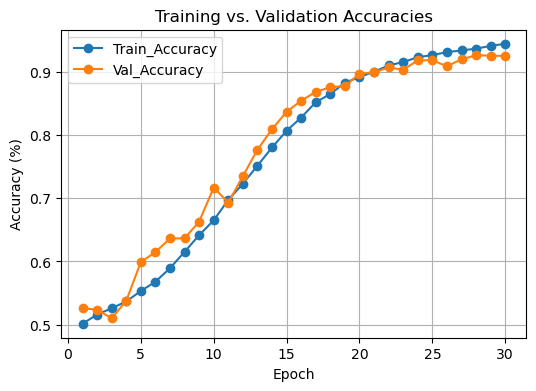

In [10]:
#Training vs Validation accuracies
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train_Accuracy', marker='o')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Val_Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracies')
plt.legend()
plt.grid(True)
plt.show()

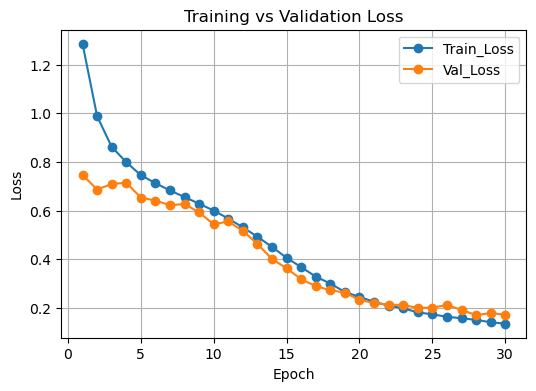

In [12]:
#Training vs Validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train_Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val_Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# Calculate training precision
train_precision = precision_score(train_targets, train_preds)

# Calculate training recall
train_recall = recall_score(train_targets, train_preds)

# Calculate training AUC
train_auc = roc_auc_score(train_targets, train_preds)

# Calculate confusion matrix for training
train_conf_matrix = confusion_matrix(train_targets, train_preds)

# Calculate training sensitivity (True Positive Rate)
train_sensitivity = train_conf_matrix[1, 1] / (train_conf_matrix[1, 0] + train_conf_matrix[1, 1])

# Calculate training specificity (True Negative Rate)
train_specificity = train_conf_matrix[0, 0] / (train_conf_matrix[0, 0] + train_conf_matrix[0, 1])

print(f'Training Precision: {train_precision:.2f}')
print(f'Training Recall: {train_recall:.2f}')
print(f'Training AUC: {train_auc:.2f}')
print(f'Training Sensitivity: {train_sensitivity:.2f}')
print(f'Training Specificity: {train_specificity:.2f}')


Training Precision: 0.95

Training Recall: 0.94

Training AUC: 0.94

Training Sensitivity: 0.94

Training Specificity: 0.95


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# Calculate validation precision
val_precision = precision_score(val_targets, val_preds)

# Calculate validation recall
val_recall = recall_score(val_targets, val_preds)

# Calculate validation AUC
val_auc = roc_auc_score(val_targets, val_preds)

# Calculate confusion matrix for validation
val_conf_matrix = confusion_matrix(val_targets, val_preds)

# Calculate validation sensitivity (True Positive Rate)
val_sensitivity = val_conf_matrix[1, 1] / (val_conf_matrix[1, 0] + val_conf_matrix[1, 1])

# Calculate validation specificity (True Negative Rate)
val_specificity = val_conf_matrix[0, 0] / (val_conf_matrix[0, 0] + val_conf_matrix[0, 1])

print(f'Validation Precision: {val_precision:.2f}')
print(f'Validation Recall: {val_recall:.2f}')
print(f'Validation AUC: {val_auc:.2f}')
print(f'Validation Sensitivity: {val_sensitivity:.2f}')
print(f'Validation Specificity: {val_specificity:.2f}')


Validation Precision: 0.93

Validation Recall: 0.92

Validation AUC: 0.92

Validation Sensitivity: 0.92

Validation Specificity: 0.93


In [17]:
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, f1_score, recall_score

# Initialize empty lists to store true labels and predicted class probabilities
true_labels = []
predicted_probs = []

# Set the model to evaluation mode
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        
        # Get the predicted class probabilities using softmax
        predicted_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())  # Probability of class 1
        
        # Store true labels
        true_labels.extend(labels.cpu().numpy())


# Calculate the accuracy
predicted_labels = [1 if prob >= 0.5 else 0 for prob in predicted_probs]
accuracy = accuracy_score(true_labels, predicted_labels)

# Calculate the AUC
roc_auc = roc_auc_score(true_labels, predicted_probs)

# Calculate precision, recall, and F1 score
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

# Calculate sensitivity (True Positive Rate)
conf_matrix = confusion_matrix(true_labels, predicted_labels)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])

# Calculate specificity (True Negative Rate)
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

# Print the results
print(f'AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall (Sensitivity): {recall:.2f}')
print(f'Specificity: {specificity:.2f}')
print(f'F1 Score: {f1:.2f}')

AUC: 0.98

Accuracy: 0.92

Precision: 0.93

Recall (Sensitivity): 0.91

Specificity: 0.94

F1 Score: 0.92


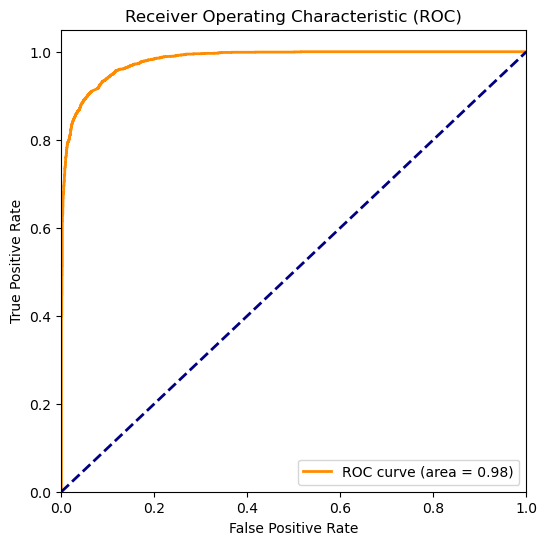

In [18]:
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

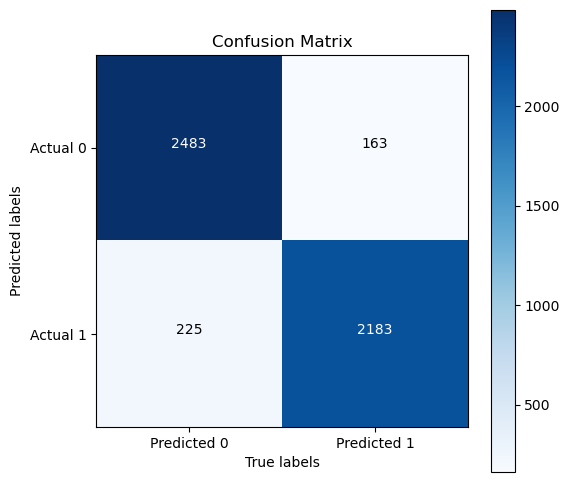

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Access values from the confusion matrix
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

# Now you can use these values as needed

# Define the confusion matrix
conf_matrix = np.array([[TN, FP], [FN, TP]])  

# Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate cells with their values
thresh = conf_matrix.max() / 2.0  # Set a threshold for text coloring
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()


# COMPLETE DATA

In [2]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 1]  # 'Image_paths' is the column containing file paths
        img_path = img_path.replace("E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png",'/kaggle/input/autism')
        img_path = img_path.replace("\\",'/')

        image = Image.open(img_path)
        
        # Convert single-channel image to RGB
        if image.mode == 'L':
            image = image.convert('RGB')

        label = int(self.data.iloc[index, 3])  # 'LABEL' is the column containing labels (0 or 1)

        if self.transform:
            image = self.transform(image)
        
        # Convert PIL image to a NumPy array
        image = np.array(image)

        return image, label

# Load your dataset without normalization for the mean and std calculation
raw_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels.csv', transform=None)
# Initialize lists to store channel-wise mean and standard deviation
channel_means = [0.0, 0.0, 0.0]
channel_stds = [0.0, 0.0, 0.0]

# Iterate through your dataset to calculate channel-wise mean and std
for sample in raw_dataset:
    image, _ = sample  # Assuming the label is not used for this calculation
    for i in range(3):  # Assuming your images have 3 channels (R, G, B)
        channel_means[i] += image[i, :, :].mean()
        channel_stds[i] += image[i, :, :].std()

# Calculate the mean and std values across the entire dataset
num_samples = len(raw_dataset)
mean = [c_mean / num_samples for c_mean in channel_means]
std = [c_std / num_samples for c_std in channel_stds]

# Define the transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 pixels
    transforms.ToTensor(),  # Convert to a PyTorch tensor
    transforms.Normalize(mean, std)  # Normalize using the calculated mean and std
])

# Define batch size
batch_size = 64

# Create train and test data loaders
train_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_train.csv', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_test.csv', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

val_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_validation.csv', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


In [4]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Test dataset size: {len(val_dataset)}")

Train dataset size: 72367
Test dataset size: 20102
Test dataset size: 8041


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the CNN model
class Autism_NadamCNN(nn.Module):
    def __init__(self):
        super(Autism_NadamCNN, self).__init__()
        
        # Convolution Layer 1 (16 filters, Window size = 3x3) + Leaky ReLU
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.leakyrelu1 = nn.LeakyReLU(0.1)
        
        # Maxpooling Layer 1 (Window size=2x2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 1 (Proportion = 20%)
        self.dropout1 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 2 (32 filters, Window size = 3x3) + Leaky ReLU
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.leakyrelu2 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 1
        self.batchnorm1 = nn.BatchNorm2d(32)
        
        # Maxpooling Layer 2 (Window size=2x2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 2 (Proportion = 20%)
        self.dropout2 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 3 (64 filters, Window size = 3x3) + Leaky ReLU
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.leakyrelu3 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 2
        self.batchnorm2 = nn.BatchNorm2d(64)
        
        # Maxpooling Layer 3 (Window size=2x2)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 3 (Proportion = 20%)
        self.dropout3 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 4 (128 filters, Window size = 3x3) + Leaky ReLU
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.leakyrelu4 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 3
        self.batchnorm3 = nn.BatchNorm2d(128)
        
        # Maxpooling Layer 4 (Window size=2x2)
        self.maxpool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 4 (Proportion = 20%)
        self.dropout4 = nn.Dropout2d(p=0.2)
        
        # Convolution Layer 5 (256 filters, Window size = 3x3) + Leaky ReLU
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.leakyrelu5 = nn.LeakyReLU(0.1)
        
        # Batch Normalization Layer 4
        self.batchnorm4 = nn.BatchNorm2d(256)
        
        # Maxpooling Layer 5 (Window size=2x2)
        self.maxpool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout Layer 5 (Proportion = 20%)
        self.dropout5 = nn.Dropout2d(p=0.2)
        
        # Flattening Layer
        self.flatten = nn.Flatten()
        
        # Fully Connected Layer (Neurons = 100) + Leaky ReLU
        self.fc1 = nn.Linear(7*7*256, 100)
            
    def forward(self, x):
        # Forward pass through the layers
        x = self.leakyrelu1(self.conv1(x))
        x = self.maxpool1(x)
        x = self.dropout1(x)
        
        x = self.leakyrelu2(self.conv2(x))
        x = self.batchnorm1(x)
        x = self.maxpool2(x)
        x = self.dropout2(x)
        
        x = self.leakyrelu3(self.conv3(x))
        x = self.batchnorm2(x)
        x = self.maxpool3(x)
        x = self.dropout3(x)
        
        x = self.leakyrelu4(self.conv4(x))
        x = self.batchnorm3(x)
        x = self.maxpool4(x)
        x = self.dropout4(x)
        
        x = self.leakyrelu5(self.conv5(x))
        x = self.batchnorm4(x)
        x = self.maxpool5(x)
        x = self.dropout5(x)
        
        x = self.flatten(x)
        x = self.leakyrelu5(self.fc1(x))
        
        return x

# Create an instance of the AutismCNN model and move it to the GPU
model = Autism_NadamCNN().to(device)


In [6]:
import torch.nn as nn

# Define the number of output classes
num_classes = 2

criterion = nn.CrossEntropyLoss()

criterion = criterion.to(device)

In [7]:
import torch.optim as optim

# Define the hyperparameters
learning_rate = 0.001  # η
beta1 = 0.9  # β1
beta2 = 0.999  # β2
epsilon = 1e-8  # ε

# Create an instance of the Nadam optimizer with the specified hyperparameters
optimizer = optim.NAdam(model.parameters(), lr=learning_rate, betas=(beta1, beta2), eps=epsilon)


In [8]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Load your pretrained model weights here if needed
#model.load_state_dict(torch.load('Nadam_full_weights.pth'))

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 0  # Change this to the epoch you want to continue from

num_epochs = 50  # Set the total number of epochs you want to run

# Define early stopping parameters
patience = 5  # Number of epochs with no improvement after which training will stop
min_delta = 0.001  # Minimum change in validation loss to be considered as improvement
best_val_loss = float('inf')
epochs_without_improvement = 0

# Continue training for additional epochs
for epoch in range(current_epoch, num_epochs):
    model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    # Early stopping
    if avg_val_loss + min_delta < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'Nadam_full_weights.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f'Early stopping after {patience} epochs without improvement.')
            break

    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}')

print('Finished Training')


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Epoch 1/50 (Validation): 100%|██████████| 126/126 [00:31<00:00,  3.95it/s]


Epoch [1/50], Training Loss: 1.1663, Training Accuracy: 0.50
Validation Loss: 0.6933, Validation Accuracy: 0.52


Epoch 2/50 (Validation): 100%|██████████| 126/126 [00:30<00:00,  4.10it/s]


Epoch [2/50], Training Loss: 0.8626, Training Accuracy: 0.51
Validation Loss: 0.6917, Validation Accuracy: 0.52


Epoch 3/50 (Validation): 100%|██████████| 126/126 [00:31<00:00,  4.05it/s]


...

Epoch [41/50], Training Loss: 0.1667, Training Accuracy: 0.93
Validation Loss: 0.2054, Validation Accuracy: 0.91


Epoch 42/50 (Validation): 100%|██████████| 126/126 [00:29<00:00,  4.23it/s]


Epoch [42/50], Training Loss: 0.1687, Training Accuracy: 0.93
Validation Loss: 0.2037, Validation Accuracy: 0.91


Epoch 43/50 (Validation): 100%|██████████| 126/126 [00:30<00:00,  4.13it/s]

Early stopping after 5 epochs without improvement.
Finished Training


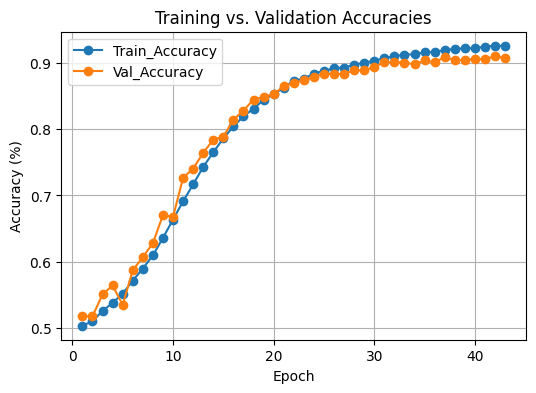

In [10]:
#Training vs Validation accuracies
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_accuracies))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_accuracies[:min_epochs], label='Train_Accuracy', marker='o')
plt.plot(range(1, min_epochs + 1), val_accuracies[:min_epochs], label='Val_Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracies')
plt.legend()
plt.grid(True)
plt.show()


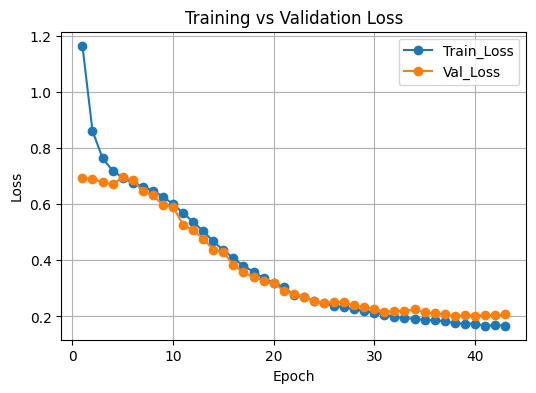

In [11]:
#Training vs Validation loss
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_losses))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_losses[:min_epochs], label='Train_Loss', marker='o')
plt.plot(range(1, min_epochs + 1), val_losses[:min_epochs], label='Val_Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, f1_score, recall_score
import torch

# Initialize empty lists to store true labels and predicted class probabilities
true_labels = []
predicted_probs = []

# Set the model to evaluation mode
model.eval()

# Move the model to the GPU
model = model.to(device)

with torch.no_grad():
    for images, labels in test_loader:
        # Move the data to the GPU
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # Get the predicted class probabilities using softmax
        predicted_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())  # Probability of class 1

        # Store true labels
        true_labels.extend(labels.cpu().numpy())

# Calculate the accuracy
predicted_labels = [1 if prob >= 0.5 else 0 for prob in predicted_probs]
accuracy = accuracy_score(true_labels, predicted_labels)

# Calculate the AUC
roc_auc = roc_auc_score(true_labels, predicted_probs)

# Calculate precision, recall, and F1 score
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

# Calculate sensitivity (True Positive Rate)
conf_matrix = confusion_matrix(true_labels, predicted_labels)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])

# Calculate specificity (True Negative Rate)
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

# Print the results
print(f'AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall (Sensitivity): {recall:.2f}')
print(f'Specificity: {specificity:.2f}')
print(f'F1 Score: {f1:.2f}')


AUC: 0.97
Accuracy: 0.91
Precision: 0.90
Recall (Sensitivity): 0.90
Specificity: 0.91
F1 Score: 0.90


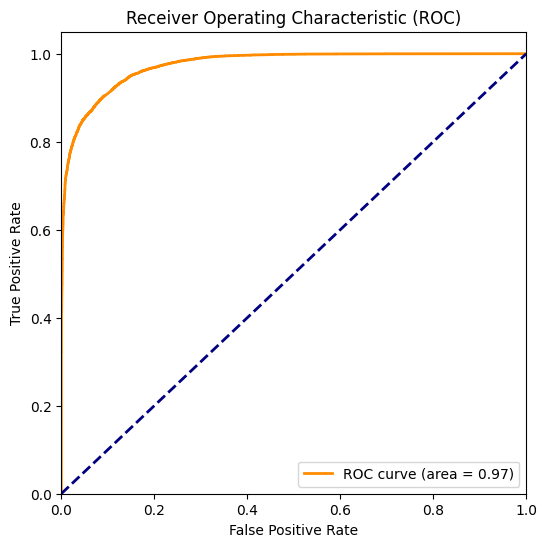

In [13]:
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

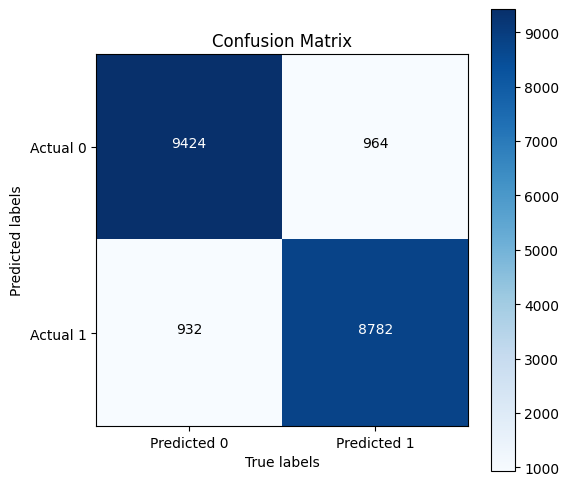

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Access values from the confusion matrix
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

# Now you can use these values as needed

# Define the confusion matrix
conf_matrix = np.array([[TN, FP], [FN, TP]])  

# Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate cells with their values
thresh = conf_matrix.max() / 2.0  # Set a threshold for text coloring
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()
